In [2]:
PRJ_PATH = "/home/seoultech/MLP/hslim/SCALE"

TRANSLATED = False
MODEL_PATH = "Qwen2.5-7B-Instruct"
DATASET = "MGSM" # Example
DATA_DIR = f"{PRJ_PATH}/data/results/{DATASET}"
FASTTEXT_MODEL_PATH = f"{PRJ_PATH}/lid.176.bin"

SKELETON_LANGUAGES = ["zh", "es", "ru", "ko", "th"]

COT_LANGUAGES = ["kk", "ky", "mn", "ug", "hy", "lo", "eu", "mt", "am", "ne", "si", "ps", "sd", "pa", "gu", "mr", "or", "ta", "ml"]
# COT_LANGUAGES = ["ta", "kn", "my", "km", "am", "yo", "si", "gu", "ne", "uz", "ky", "ceb", "eu", "gn", "hy", "jv", "ka", "kk", "ku", "lo", "mg", "ml", "mn", "mr", "mt", "or", "pa", "ps", "qu", "sd", "so", "su", "tg", "ug"]

LANGUAGE_NAMES = {
        "ta": "Tamil", "kn": "Kannada", "my": "Burmese",
        "km": "Khmer", "am": "Amharic", "yo": "Yoruba",
        "si": "Sinhala", "gu": "Gujarati", "ne": "Nepali",
        "uz": "Uzbek", "ky": "Kyrgyz",
        "ceb": "Cebuano", "eu": "Basque", "gn": "Guarani",
        "hy": "Armenian", "jv": "Javanese", "ka": "Georgian",
        "kk": "Kazakh", "ku": "Kurdish", "lo": "Lao",
        "mg": "Malagasy", "ml": "Malayalam", "mn": "Mongolian",
        "mr": "Marathi", "mt": "Maltese", "or": "Odia",
        "pa": "Punjabi", "ps": "Pashto", "qu": "Quechua",
        "sd": "Sindhi", "so": "Somali", "su": "Sundanese",
        "tg": "Tajik", "ug": "Uyghur",
        "en": "English", "zh": "Chinese", "es": "Spanish",
        "ko": "Korean", "th": "Thai", "sw": "Swahili", "te": "Telugu",
    }
print(f"Model: {MODEL_PATH}")
print(f"Skeleton Languages: {SKELETON_LANGUAGES}")
print(f"CoT Languages: {COT_LANGUAGES}")

Model: Qwen2.5-7B-Instruct
Skeleton Languages: ['zh', 'es', 'ru', 'ko', 'th']
CoT Languages: ['kk', 'ky', 'mn', 'ug', 'hy', 'lo', 'eu', 'mt', 'am', 'ne', 'si', 'ps', 'sd', 'pa', 'gu', 'mr', 'or', 'ta', 'ml']


In [ ]:
# ========================================
# Imports & FastText 로드
# ========================================
import fasttext
import json
import os
from collections import defaultdict
from multiprocessing import Pool, cpu_count
from tqdm import tqdm
from math_verify import parse, verify
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from statsmodels.stats.multitest import multipletests
import math
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import chi2
from scipy.stats import binomtest

fasttext.FastText.eprint = lambda x: None
lang_model = fasttext.load_model(FASTTEXT_MODEL_PATH)
print("FastText model loaded successfully")

FastText model loaded successfully


In [ ]:

# ========================================
# Helper Functions
# ========================================
from scipy.stats import binomtest

def calculate_mcnemar_pvalue(results):
    """
    McNemar's exact test (two-sided binomial).
    Always uses exact version for consistency.
    """
    b_count = 0  # Base correct, Target incorrect
    c_count = 0  # Base incorrect, Target correct
    
    for r in results:
        correct_a, correct_b, _ = r
        if correct_a and not correct_b:
            b_count += 1
        elif not correct_a and correct_b:
            c_count += 1

    n_discordant = b_count + c_count
    
    if n_discordant == 0:
        return 1.0
    
    # Exact binomial test: H0: c ~ Binom(n_discordant, 0.5)
    result = binomtest(c_count, n_discordant, 0.5, 
                       alternative='two-sided')
    return result.pvalue

def paired_bootstrap_delta_ci(valid_results, n_boot=5000, alpha=0.05, seed=42):
    """
    Paired bootstrap CI for accuracy difference (target - baseline), in percentage points.

    Args:
        valid_results: list of tuples (correct_a, correct_b, 0)
    Returns:
        (delta_mean, ci_lower, ci_upper)
    """
    if len(valid_results) == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(seed)
    arr = np.array(valid_results)[:, :2]  # shape (n, 2)
    n = len(arr)

    deltas = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        sample = arr[idx]
        acc_a = sample[:, 0].mean() * 100
        acc_b = sample[:, 1].mean() * 100
        deltas.append(acc_b - acc_a)

    deltas = np.array(deltas)
    delta_mean = arr[:, 1].mean() * 100 - arr[:, 0].mean() * 100
    ci_lower = np.percentile(deltas, 100 * (alpha / 2))
    ci_upper = np.percentile(deltas, 100 * (1 - alpha / 2))

    return delta_mean, ci_lower, ci_upper

def detect_language(text):
    global lang_model
    if text is None or not isinstance(text, str):
        return "unk"
    text = text.replace("\n", " ").strip()
    if len(text) < 2:
        return "unk"
    try:
        labels, probs = lang_model.predict(text, k=1)
        if not probs or len(probs) == 0:
            return "unk"
        return labels[0].replace("__label__", "")
    except:
        return "unk"


def load_jsonl(filepath):
    data = []
    if not os.path.exists(filepath):
        print(f"⚠️ File not found: {filepath}")
        return None
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            try:
                data.append(json.loads(line))
            except:
                pass
    return data



def add_detected_languages(data, detect_skeleton=False):
    for item in tqdm(data, desc="Detecting languages"):
        responses = item.get('responses', [])
        if responses and isinstance(responses, list) and len(responses) > 0:
            resp_text = responses[0] if isinstance(responses[0], str) else ""
            item['detected_response_language'] = detect_language(resp_text)
        else:
            item['detected_response_language'] = "unk"
        
        if detect_skeleton:
            skeleton = item.get('skeleton', [])
            if isinstance(skeleton, list) and len(skeleton) > 0:
                skel_text = skeleton[0] if isinstance(skeleton[0], str) else ""
            elif isinstance(skeleton, str):
                skel_text = skeleton
            else:
                skel_text = ""
            item['detected_skeleton_language'] = detect_language(skel_text)
    return data


def group_by_language(data):
    grouped = defaultdict(list)
    for item in data:
        lang = item.get('question_language', 'unknown')
        grouped[lang].append(item)
    return grouped


def evaluate_single_example(args):
    example_a, example_b = args
    response_a = example_a['responses'][0] if example_a.get('responses') else ""
    response_b = example_b['responses'][0] if example_b.get('responses') else ""
    try:
        gold = parse(str(example_a['answer']))
        pred_a = parse(str(response_a))
        correct_a = int(verify(gold, pred_a))
        pred_b = parse(str(response_b))
        correct_b = int(verify(gold, pred_b))
        return correct_a, correct_b, 0
    except:
        return 0, 0, 1


def get_baseline_path(tr):
    if tr:
        path = os.path.join(DATA_DIR, f"{MODEL_PATH}-skeleton_multiturn_skelLang-en-Google-transQ.jsonl")
    else:
        path = os.path.join(DATA_DIR, f"{MODEL_PATH}-skeleton_multiturn_skelLang-en.jsonl")
    print("Baseline path: ", path)
    return path


def get_skellang_path(skel_lang, tr):
    if tr:
        path = os.path.join(DATA_DIR, f"{MODEL_PATH}-skeleton_multiturn_skelLang-{skel_lang}-Google-transQ.jsonl")
    else:
        path = os.path.join(DATA_DIR, f"{MODEL_PATH}-skeleton_multiturn_skelLang-{skel_lang}.jsonl")
    print("Skeleton lang path: ", path)
    return path

print("Helper functions defined.")

Helper functions defined.


In [5]:
# ========================================
# Baseline 데이터 로드
# ========================================
print("📂 Loading baseline data (English skeleton)...")
baseline_path = get_baseline_path(TRANSLATED)
baseline_data = load_jsonl(baseline_path)
if baseline_data:
    print(f"   Loaded {len(baseline_data)} examples")
    baseline_data = add_detected_languages(baseline_data, detect_skeleton=False)
    baseline_grouped = group_by_language(baseline_data)
    print(f"   Languages: {list(baseline_grouped.keys())}")
else:
    print("❌ Baseline file not found!")

📂 Loading baseline data (English skeleton)...
Baseline path:  /home/seoultech/MLP/hslim/SCALE/data/results/MGSM/Qwen2.5-7B-Instruct-skeleton_multiturn_skelLang-en.jsonl
   Loaded 8500 examples


Detecting languages: 100%|██████████| 8500/8500 [00:00<00:00, 14930.14it/s]

   Languages: ['ta', 'kn', 'my', 'km', 'am', 'yo', 'si', 'gu', 'ne', 'uz', 'ky', 'ceb', 'eu', 'gn', 'hy', 'jv', 'ka', 'kk', 'ku', 'lo', 'mg', 'ml', 'mn', 'mr', 'mt', 'or', 'pa', 'ps', 'qu', 'sd', 'so', 'su', 'tg', 'ug']


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from multiprocessing import Pool, cpu_count
from tqdm import tqdm

def calculate_cohens_h(acc_a, acc_b):
    """
    두 정확도(비율) 간의 effect size 계산
    0.2: small, 0.5: medium, 0.8: large
    """
    p1 = acc_a / 100
    p2 = acc_b / 100
    h = 2 * np.arcsin(np.sqrt(p2)) - 2 * np.arcsin(np.sqrt(p1))
    return abs(h)


# ========================================
# 모든 Skeleton 언어에 대해 비교 수행 (정확한 ID 매칭 + 에러 쌍 제외 + McNemar)
# ========================================
delta_matrix = defaultdict(dict)
accuracy_baseline = defaultdict(dict)
accuracy_target = defaultdict(dict)
sample_counts = defaultdict(dict)
pvalue_matrix = defaultdict(dict) # 원본 p-value
effect_size_matrix = defaultdict(dict)  # 추가

results_table = []  # 최종 csv 저장용


# 1. Baseline 데이터를 'question_language'와 'original_id'의 조합을 키(Key)로 하여 딕셔너리로 변환
baseline_dict = {}
for item in baseline_data:
    q_lang = item.get('question_language', 'unk')
    orig_id = item.get('original_id', 'unk')
    
    # 두 값을 이어붙여 강력한 고유 식별 키(예: "ta_0", "kk_123") 생성
    match_key = f"{q_lang}_{orig_id}"
    baseline_dict[match_key] = item


for skel_lang in SKELETON_LANGUAGES:
    print(f"\n{'─'*60}")
    print(f"📊 Skeleton Language: {skel_lang.upper()} ({LANGUAGE_NAMES.get(skel_lang, skel_lang)})")
    print(f"{'─'*60}")
    
    target_path = get_skellang_path(skel_lang, TRANSLATED)
    target_data = load_jsonl(target_path)
    if target_data is None:
        print(f"   ⚠️ File not found, skipping")
        continue
    print(f"   Loaded {len(target_data)} examples")
    target_data = add_detected_languages(target_data, detect_skeleton=True)
    target_grouped = group_by_language(target_data)
    
    for cot_lang in COT_LANGUAGES:
        target_lang_data = target_grouped.get(cot_lang, [])
        
        if not target_lang_data:
            print(f"   [{cot_lang}] No data")
            continue
        
        filtered_pairs = []
        filtered_a, filtered_b, filtered_skel, miss_match = 0, 0, 0, 0
        
        # Target 데이터를 돌면서 Baseline의 매칭 키(question_language + original_id)와 동일한 짝을 찾음
        for item_b in target_lang_data:
            b_q_lang = item_b.get('question_language', 'unk')
            b_orig_id = item_b.get('original_id', 'unk')
            b_key = f"{b_q_lang}_{b_orig_id}"
            
            item_a = baseline_dict.get(b_key)
            
            # 매칭되는 원본 데이터가 없으면 패스 (개수 차이로 인해 짝이 없는 경우 여기서 걸러짐)
            if item_a is None:
                miss_match += 1
                continue
                
            resp_lang_a = item_a.get('detected_response_language', 'unk')
            if resp_lang_a != cot_lang:
                filtered_a += 1
                continue
            
            resp_lang_b = item_b.get('detected_response_language', 'unk')
            if resp_lang_b != cot_lang:
                filtered_b += 1
                continue
            
            detected_skel = item_b.get('detected_skeleton_language', 'unk')
            if detected_skel != skel_lang:
                filtered_skel += 1
                continue
            
            filtered_pairs.append((item_a, item_b))
        
        print(f"   [{cot_lang}] Total eval: {len(target_lang_data)}, Match failed: {miss_match}, A miss: {filtered_a}, B miss: {filtered_b}, Skel miss: {filtered_skel}, Valid pairs: {len(filtered_pairs)}")
        
        if len(filtered_pairs) < 10:
            continue
        
        with Pool(cpu_count()) as pool:
            results = list(tqdm(pool.imap(evaluate_single_example, filtered_pairs),
                                total=len(filtered_pairs), desc=f"   Eval {cot_lang}", leave=False))
        
        # 핵심: 파싱 에러(r[2] == 1)인 항목은 비교(p-value) 대상에서 철저히 제외
        valid_results = [r for r in results if r[2] == 0]
        invalid_count = len(results) - len(valid_results)
        
        total = len(valid_results)
        if total == 0:
            continue
            
        correct_a = sum(r[0] for r in valid_results)
        correct_b = sum(r[1] for r in valid_results)
        
        acc_a = correct_a / total * 100
        acc_b = correct_b / total * 100
        delta = acc_b - acc_a
        
        # McNemar 테스트 (독립적인 p-value) 계산
        p_value = calculate_mcnemar_pvalue(valid_results)
        pvalue_matrix[skel_lang][cot_lang] = p_value
        
        h = calculate_cohens_h(acc_a, acc_b)
        effect_size_matrix[skel_lang][cot_lang] = h
        
        delta_matrix[skel_lang][cot_lang] = delta
        accuracy_baseline[skel_lang][cot_lang] = acc_a
        accuracy_target[skel_lang][cot_lang] = acc_b
        sample_counts[skel_lang][cot_lang] = total
        
        print(f"   [{cot_lang}] Error excluded: {invalid_count} | "
            f"Base: {acc_a:.2f}%, Target: {acc_b:.2f}%, "
            f"Delta: {delta:+.2f}%, p-value: {p_value:.4f}, "
            f"Cohen's h: {h:.3f} "
            f"({'large' if h >= 0.8 else 'medium' if h >= 0.5 else 'small'})")

print("\n✅ Data evaluation and independent McNemar p-value calculation finished!")



────────────────────────────────────────────────────────────
📊 Skeleton Language: ZH (Chinese)
────────────────────────────────────────────────────────────
Skeleton lang path:  /home/seoultech/MLP/hslim/SCALE/data/results/MGSM/Qwen2.5-7B-Instruct-skeleton_multiturn_skelLang-zh.jsonl
   Loaded 8500 examples


Detecting languages: 100%|██████████| 8500/8500 [00:00<00:00, 13002.82it/s]

   [kk] Total eval: 250, Match failed: 0, A miss: 1, B miss: 7, Skel miss: 0, Valid pairs: 242


   [kk] Error excluded: 0 | Base: 52.07%, Target: 48.76%, Delta: -3.31%, p-value: 0.3817, Cohen's h: 0.066 (small)
   [ky] Total eval: 250, Match failed: 0, A miss: 1, B miss: 8, Skel miss: 1, Valid pairs: 240


   [ky] Error excluded: 0 | Base: 39.17%, Target: 36.67%, Delta: -2.50%, p-value: 0.4885, Cohen's h: 0.052 (small)
   [mn] Total eval: 250, Match failed: 0, A miss: 5, B miss: 4, Skel miss: 0, Valid pairs: 241


...

   [gu] Error excluded: 0 | Base: 48.00%, Target: 44.00%, Delta: -4.00%, p-value: 0.2370, Cohen's h: 0.080 (small)
   [mr] Total eval: 250, Match failed: 0, A miss: 2, B miss: 0, Skel miss: 2, Valid pairs: 246


   [mr] Error excluded: 0 | Base: 47.15%, Target: 46.75%, Delta: -0.41%, p-value: 1.0000, Cohen's h: 0.008 (small)
   [or] Total eval: 250, Match failed: 0, A miss: 1, B miss: 0, Skel miss: 2, Valid pairs: 247


   [or] Error excluded: 0 | Base: 43.72%, Target: 40.49%, Delta: -3.24%, p-value: 0.4160, Cohen's h: 0.066 (small)
   [ta] Total eval: 250, Match failed: 0, A miss: 0, B miss: 1, Skel miss: 0, Valid pairs: 249


   [ta] Error excluded: 0 | Base: 49.80%, Target: 45.38%, Delta: -4.42%, p-value: 0.2284, Cohen's h: 0.088 (small)
   [ml] Total eval: 250, Match failed: 0, A miss: 1, B miss: 0, Skel miss: 0, Valid pairs: 249


   [ml] Error excluded: 0 | Base: 46.59%, Target: 42.17%, Delta: -4.42%, p-value: 0.1524, Cohen's h: 0.089 (small)

✅ Data evaluation and independent McNemar p-value calculation finished!


✅ Heatmap saved to:  /home/seoultech/MLP/hslim/SCALE/skeleton_lang_delta_heatmap_McNemar_Qwen2.5-7B-Instruct.pdf


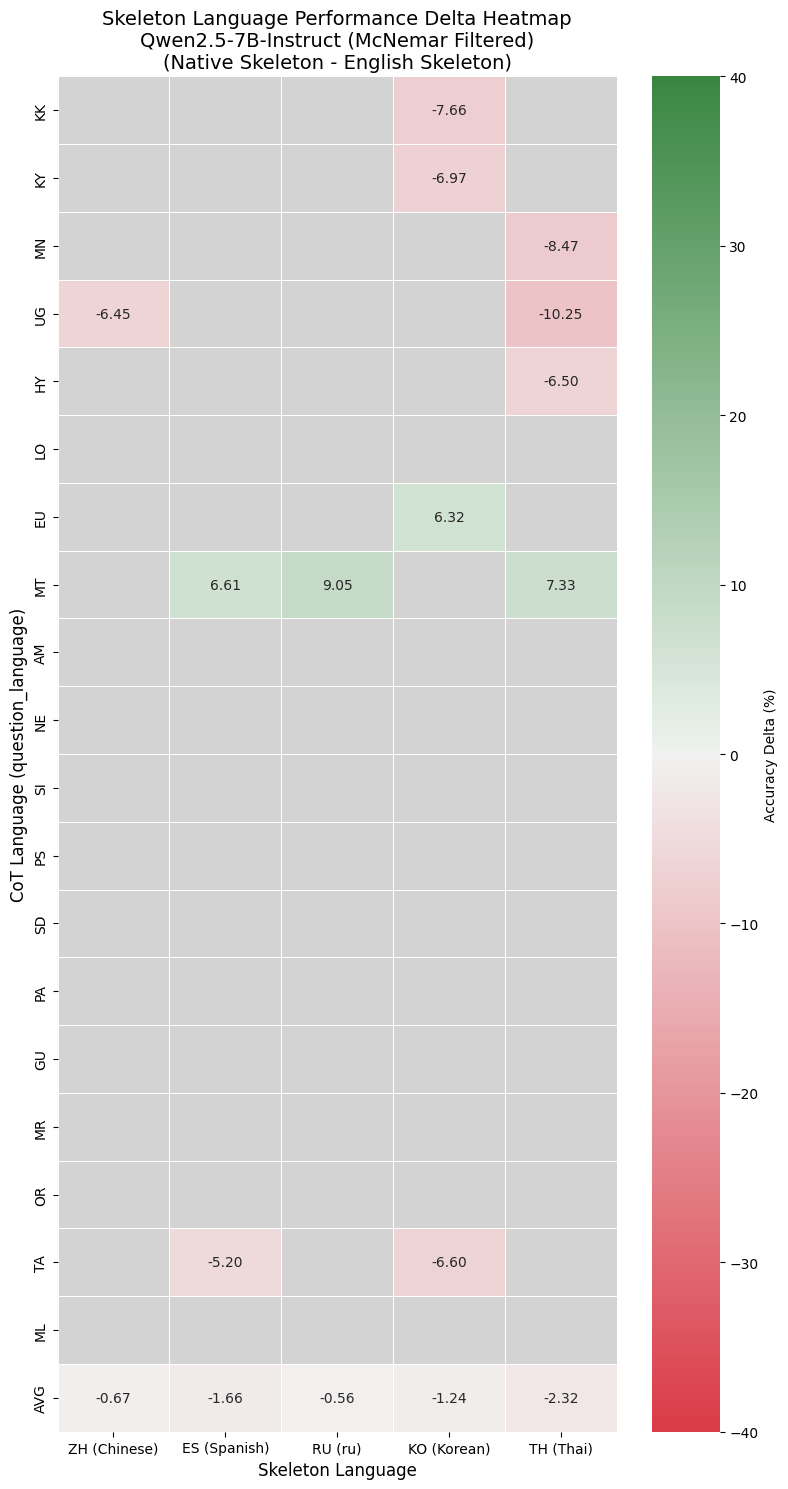

In [7]:

# ========================================
# 히트맵 생성 (p >= 0.05 기준으로 Grey 아웃)
# ========================================
df = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)
df_p = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)
df_effect = pd.DataFrame(
    index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float
)

for skel_lang in SKELETON_LANGUAGES:
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
            df.loc[cot_lang, skel_lang] = delta_matrix[skel_lang][cot_lang]
            df_p.loc[cot_lang, skel_lang] = pvalue_matrix[skel_lang][cot_lang]
            df_effect.loc[cot_lang, skel_lang] = effect_size_matrix[skel_lang][cot_lang]
        else:
            df.loc[cot_lang, skel_lang] = np.nan
            df_p.loc[cot_lang, skel_lang] = np.nan
            df_effect.loc[cot_lang, skel_lang] = np.nan

df_effect.loc["AVG"] = 0.0
x_labels = [f"{lang.upper()} ({LANGUAGE_NAMES.get(lang, lang)})" for lang in SKELETON_LANGUAGES]
y_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]

df.loc["AVG"] = df.mean(axis=0, skipna=True)
df_p.loc["AVG"] = 0.0 # Ensure AVG row exists in mask (히트맵에 항상 표시되도록)

y_labels = [*y_labels, "AVG"]

plt.figure(figsize=(8, 15))
cmap = sns.diverging_palette(10, 130, as_cmap=True)
mask = (df_p >= 0.1) & (df_effect < 0.2)

ax = sns.heatmap(
    df.astype(float),
    mask=mask, # Mask insignificant results based on independent raw p-values
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    vmin=-40,
    vmax=40,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Accuracy Delta (%)'}
)
ax.set_facecolor('lightgrey') # Grey out masked cells

plt.title(f"Skeleton Language Performance Delta Heatmap\n{MODEL_PATH} (McNemar Filtered)\n(Native Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (question_language)", fontsize=12)

# 저장 경로 설정
if TRANSLATED:
    SAVE_PATH = f"{PRJ_PATH}/TransQ_skeleton_lang_delta_heatmap_McNemar_{MODEL_PATH}.pdf"
else:
    SAVE_PATH = f"{PRJ_PATH}/skeleton_lang_delta_heatmap_McNemar_{MODEL_PATH}.pdf"

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=500, bbox_inches='tight')
print("✅ Heatmap saved to: ", SAVE_PATH)
plt.show()


In [8]:
# ========================================
# p-value 구간별 결과 확인
# 기존 pvalue_matrix, delta_matrix, sample_counts 활용
# ========================================

print("=" * 90)
print("p < 0.05 (Significant)")
print("=" * 90)

sig_005 = []
sig_01 = []
all_results = []

for skel_lang in SKELETON_LANGUAGES:
    for cot_lang in COT_LANGUAGES:
        if skel_lang in pvalue_matrix and cot_lang in pvalue_matrix[skel_lang]:
            p = pvalue_matrix[skel_lang][cot_lang]
            d = delta_matrix[skel_lang][cot_lang]
            n = sample_counts[skel_lang][cot_lang]
            h = effect_size_matrix.get(skel_lang, {}).get(cot_lang, None)
            
            entry = {
                'skel': skel_lang.upper(),
                'cot': cot_lang.upper(),
                'delta': d,
                'p': p,
                'n': n,
                'h': h,
            }
            all_results.append(entry)
            
            if p < 0.05:
                sig_005.append(entry)
            elif p < 0.10:
                sig_01.append(entry)

# p < 0.05
for e in sorted(sig_005, key=lambda x: x['p']):
    h_str = f"h={e['h']:.3f}" if e['h'] else ""
    print(f"  Skel: {e['skel']:<4} | CoT: {e['cot']:<4} | "
          f"Delta: {e['delta']:>+7.2f}% | N={e['n']:>3} | "
          f"p={e['p']:.4f} {h_str}")

print(f"\nTotal: {len(sig_005)}")

print("\n" + "=" * 90)
print("0.05 <= p < 0.10 (Marginally Significant)")
print("=" * 90)

for e in sorted(sig_01, key=lambda x: x['p']):
    h_str = f"h={e['h']:.3f}" if e['h'] else ""
    print(f"  Skel: {e['skel']:<4} | CoT: {e['cot']:<4} | "
          f"Delta: {e['delta']:>+7.2f}% | N={e['n']:>3} | "
          f"p={e['p']:.4f} {h_str}")

print(f"\nTotal: {len(sig_01)}")

print("\n" + "=" * 90)
print("Summary")
print("=" * 90)
print(f"  Total comparisons:        {len(all_results)}")
print(f"  p < 0.05 (significant):   {len(sig_005)}")
print(f"  0.05 <= p < 0.10 (marginal): {len(sig_01)}")
print(f"  p >= 0.10:                {len(all_results) - len(sig_005) - len(sig_01)}")

p < 0.05 (Significant)
  Skel: RU   | CoT: MT   | Delta:   +9.05% | N=232 | p=0.0005 h=0.216
  Skel: TH   | CoT: UG   | Delta:  -10.25% | N=244 | p=0.0015 h=0.219
  Skel: TH   | CoT: MT   | Delta:   +7.33% | N=232 | p=0.0046 h=0.177
  Skel: TH   | CoT: MN   | Delta:   -8.47% | N=236 | p=0.0151 h=0.186
  Skel: KO   | CoT: KK   | Delta:   -7.66% | N=209 | p=0.0293 h=0.153
  Skel: ES   | CoT: MT   | Delta:   +6.61% | N=227 | p=0.0400 h=0.157
  Skel: KO   | CoT: KY   | Delta:   -6.97% | N=201 | p=0.0488 h=0.145

Total: 7

0.05 <= p < 0.10 (Marginally Significant)
  Skel: TH   | CoT: HY   | Delta:   -6.50% | N=246 | p=0.0519 h=0.130
  Skel: ZH   | CoT: UG   | Delta:   -6.45% | N=248 | p=0.0559 h=0.136
  Skel: KO   | CoT: TA   | Delta:   -6.60% | N=212 | p=0.0649 h=0.133
  Skel: KO   | CoT: EU   | Delta:   +6.32% | N=174 | p=0.0708 h=0.156
  Skel: ES   | CoT: TA   | Delta:   -5.20% | N=250 | p=0.0984 h=0.104

Total: 5

Summary
  Total comparisons:        95
  p < 0.05 (significant):   7
  0.

✅ Heatmap saved to:  /home/seoultech/MLP/hslim/SCALE/skeleton_lang_delta_heatmap_McNemar_Qwen2.5-7B-Instruct.pdf


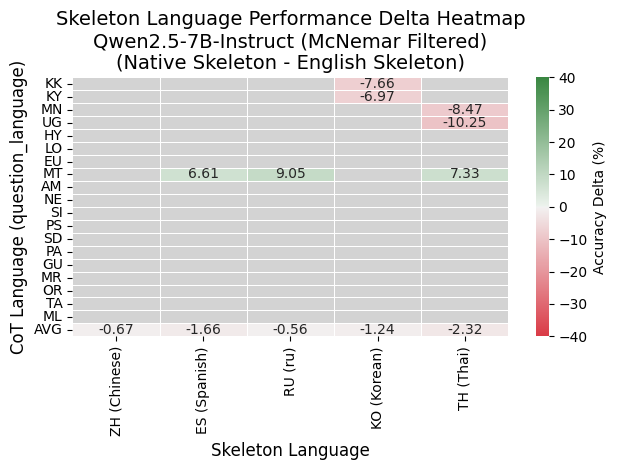

In [9]:
mask = (df_p >= 0.05) & (df_effect < 0.2)

ax = sns.heatmap(
    df.astype(float),
    mask=mask, # Mask insignificant results based on independent raw p-values
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    vmin=-40,
    vmax=40,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Accuracy Delta (%)'}
)
ax.set_facecolor('lightgrey') # Grey out masked cells

plt.title(f"Skeleton Language Performance Delta Heatmap\n{MODEL_PATH} (McNemar Filtered)\n(Native Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (question_language)", fontsize=12)

# 저장 경로 설정
if TRANSLATED:
    SAVE_PATH = f"{PRJ_PATH}/TransQ_skeleton_lang_delta_heatmap_McNemar_{MODEL_PATH}.pdf"
else:
    SAVE_PATH = f"{PRJ_PATH}/skeleton_lang_delta_heatmap_McNemar_{MODEL_PATH}.pdf"

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=500, bbox_inches='tight')
print("✅ Heatmap saved to: ", SAVE_PATH)
plt.show()

In [ ]:
# ========================================
# 모든 Skeleton 언어에 대해 비교 수행
# ========================================

delta_matrix = defaultdict(dict)
accuracy_baseline = defaultdict(dict)
accuracy_target = defaultdict(dict)
sample_counts = defaultdict(dict)
pvalue_matrix = defaultdict(dict)

for skel_lang in SKELETON_LANGUAGES:
    print(f"\n{'─'*60}")
    print(f"📊 Skeleton Language: {skel_lang.upper()} ({LANGUAGE_NAMES.get(skel_lang, skel_lang)})")
    print(f"{'─'*60}")
    
    target_path = get_skellang_path(skel_lang, TRANSLATED)
    target_data = load_jsonl(target_path)
    if target_data is None:
        print(f"   ⚠️ File not found, skipping")
        continue
    print(f"   Loaded {len(target_data)} examples")
    target_data = add_detected_languages(target_data, detect_skeleton=True)
    target_grouped = group_by_language(target_data)
    
    for cot_lang in COT_LANGUAGES:
        baseline_lang_data = baseline_grouped.get(cot_lang, [])
        target_lang_data = target_grouped.get(cot_lang, [])
        
        if not baseline_lang_data or not target_lang_data:
            print(f"   [{cot_lang}] No data")
            continue
        
        min_len = min(len(baseline_lang_data), len(target_lang_data))
        baseline_lang_data = baseline_lang_data[:min_len]
        target_lang_data = target_lang_data[:min_len]
        
        filtered_pairs = []
        filtered_a, filtered_b, filtered_skel = 0, 0, 0
        
        for item_a, item_b in zip(baseline_lang_data, target_lang_data):
            resp_lang_a = item_a.get('detected_response_language', 'unk')
            if resp_lang_a != cot_lang:
                filtered_a += 1
                continue
            
            resp_lang_b = item_b.get('detected_response_language', 'unk')
            if resp_lang_b != cot_lang:
                filtered_b += 1
                continue
            
            detected_skel = item_b.get('detected_skeleton_language', 'unk')
            if detected_skel != skel_lang:
                filtered_skel += 1
                continue
            
            filtered_pairs.append((item_a, item_b))
        
        print(f"   [{cot_lang}] Total: {min_len}, A miss: {filtered_a}, B miss: {filtered_b}, Skel miss: {filtered_skel}, Valid: {len(filtered_pairs)}")
        
        if len(filtered_pairs) < 10:
            continue
        
        with Pool(cpu_count()) as pool:
            results = list(tqdm(pool.imap(evaluate_single_example, filtered_pairs),
                                total=len(filtered_pairs), desc=f"   Eval {cot_lang}", leave=False))
        
        total = len(results)
        correct_a = sum(r[0] for r in results)
        correct_b = sum(r[1] for r in results)
        
        acc_a = correct_a / total * 100
        acc_b = correct_b / total * 100
        delta = acc_b - acc_a
        
        p_value = calculate_mcnemar_pvalue(results)
        pvalue_matrix[skel_lang][cot_lang] = p_value
        
        delta_matrix[skel_lang][cot_lang] = delta
        accuracy_baseline[skel_lang][cot_lang] = acc_a
        accuracy_target[skel_lang][cot_lang] = acc_b
        sample_counts[skel_lang][cot_lang] = total
        
        print(f"   [{cot_lang}] Base: {acc_a:.2f}%, Target: {acc_b:.2f}%, Delta: {delta:+.2f}%, p-value: {p_value:.4f}")

print("\n✅ Comparison completed!")

In [ ]:
print("\n" + "="*80)
print("📊 Delta Summary (Target - Baseline)")
print("="*80)

header = f"{'Skel Lang':<15}"
for cot_lang in COT_LANGUAGES:
    header += f" {cot_lang.upper():>8}"
header += f" {'AVG':>8}"
print(header)
print("-" * 80)

for skel_lang in SKELETON_LANGUAGES:
    row = f"{skel_lang.upper():<15}"
    deltas = []
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
            delta = delta_matrix[skel_lang][cot_lang]
            deltas.append(delta)
            row += f" {delta:>+7.2f}%"
        else:
            row += f" {'N/A':>8}"
    if deltas:
        avg = sum(deltas) / len(deltas)
        row += f" {avg:>+7.2f}%"
    else:
        row += f" {'N/A':>8}"
    print(row)

print("-" * 80)

In [ ]:
import pandas as pd

print("=== p < 0.05 (Statistically Significant) 인 경우의 정확도 변화(Delta) 및 p-value ===")
for skel_lang in SKELETON_LANGUAGES:
    for cot_lang in COT_LANGUAGES:
        # 데이터프레임에서 현재 언어 쌍의 p-value와 delta 값을 가져옵니다
        p_val = df_p.loc[cot_lang, skel_lang]
        delta = df.loc[cot_lang, skel_lang]
        
        # 값이 존재하고(NaN이 아님), p-value가 0.05 미만인 경우만 출력
        if pd.notna(p_val) and p_val < 0.05:
            print(f"Skeleton: {skel_lang.upper():<3} | CoT: {cot_lang.upper():<4} | Delta: {delta:>6.2f}% | p-value: {p_val:.4f}")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# df_p 데이터프레임에서 NaN을 제외한 모든 p-value를 1차원 배열로 추출
p_values = df_p.values.flatten()
p_values = p_values[~np.isnan(p_values)]

plt.figure(figsize=(10, 6))

# 히스토그램 그리기 (0부터 1까지의 범위를 세밀하게 보기 위해 bins=20 정도로 설정)
sns.histplot(p_values, bins=20, kde=True, color='skyblue', edgecolor='black')

# 유의수준 0.05 기준선 강조 (빨간 점선)
plt.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='Significance Level (0.05)')

# 그래프 꾸미기
plt.title('Distribution of McNemar p-values', fontsize=16, fontweight='bold')
plt.xlabel('p-value', fontsize=14)
plt.ylabel('Frequency (Number of Language Pairs)', fontsize=14)
plt.legend(fontsize=12)

# p-value의 특성상 x축을 0~1 사이로 고정
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

# 간단한 통계량 출력 창
sig_count = (p_values < 0.05).sum()
total_count = len(p_values)
print("=== p-value Summary ===")
print(f"Total evaluated pairs : {total_count}")
print(f"Significant (p < 0.05): {sig_count} ({(sig_count/total_count)*100:.1f}%)")
print(f"Insignificant (p >= 0.05): {total_count - sig_count} ({((total_count - sig_count)/total_count)*100:.1f}%)")


In [ ]:
import numpy as np

def calculate_bootstrap_ci(results, n_iterations=1000, alpha=0.05):
    # """
    # results: list of tuples (correct_a, correct_b, _)
    # n_iterations: 부트스트랩 샘플링 반복 횟수 (논문용으로는 1000 ~ 10000 권장)
    # alpha: 유의수준 (0.05 이면 95% 신뢰구간)
    
    # Returns: (lower_bound, upper_bound) of the Accuracy Delta in percentage
    # """
    n_samples = len(results)
    if n_samples == 0:
        return (0.0, 0.0)
        
    deltas = []
    
    # 반복 속도 향상을 위해 numpy array로 변환
    correct_a = np.array([r[0] for r in results])
    correct_b = np.array([r[1] for r in results])
    
    for _ in range(n_iterations):
        # 1. 원래 데이터에서 중복을 허용하여 같은 크기의 샘플을 무작위 추출 (Resampling with replacement)
        indices = np.random.randint(0, n_samples, size=n_samples)
        
        sample_a = correct_a[indices]
        sample_b = correct_b[indices]
        
        # 2. 추출된 샘플에서 각각의 Accuracy 계산
        acc_a = np.mean(sample_a)
        acc_b = np.mean(sample_b)
        
        # 3. Delta (Target - Baseline) 기록
        deltas.append(acc_b - acc_a)
        
    # 4. 전체 Delta 분포에서 하위 2.5%, 상위 97.5%에 해당하는 값 추출 (95% CI)
    lower_bound = np.percentile(deltas, (alpha / 2) * 100)
    upper_bound = np.percentile(deltas, (1 - alpha / 2) * 100)
    
    return lower_bound * 100, upper_bound * 100


In [ ]:

df = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)
df_p = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)
for skel_lang in SKELETON_LANGUAGES:
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
            df.loc[cot_lang, skel_lang] = delta_matrix[skel_lang][cot_lang]
            df_p.loc[cot_lang, skel_lang] = pvalue_matrix[skel_lang][cot_lang]
        else:
            df.loc[cot_lang, skel_lang] = np.nan
            df_p.loc[cot_lang, skel_lang] = np.nan



x_labels = [f"{lang.upper()} ({LANGUAGE_NAMES.get(lang, lang)})" for lang in SKELETON_LANGUAGES]
y_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]


df.loc["AVG"] = df.mean(axis=0, skipna=True)
df_p.loc["AVG"] = 0.0 # Ensure AVG row exists in mask

y_labels = [*y_labels, "AVG"]

plt.figure(figsize=(8, 15))
cmap = sns.diverging_palette(10, 130, as_cmap=True)

ax = sns.heatmap(
    df.astype(float),
    mask=df_p >= 0.05, # Mask insignificant results
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    vmin=-40,
    vmax=40,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Accuracy Delta (%)'}
)
ax.set_facecolor('lightgrey') # Grey out masked cells

plt.title(f"Skeleton Language Performance Delta Heatmap\n{MODEL_PATH}\n(Native Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (question_language)", fontsize=12)

if TRANSLATED:
    SAVE_PATH = f"{PRJ_PATH}/TransQ_skeleton_lang_delta_heatmap_{MODEL_PATH}.pdf"
else:
    SAVE_PATH = f"{PRJ_PATH}/skeleton_lang_delta_heatmap_{MODEL_PATH}.pdf"
plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=500, bbox_inches='tight')
print("✅ Heatmap saved to: skeleton_lang_delta_heatmap.png")
plt.show()


In [ ]:

df_delta = pd.DataFrame(index=SKELETON_LANGUAGES, columns=COT_LANGUAGES, dtype=float)
df_count = pd.DataFrame(index=SKELETON_LANGUAGES, columns=COT_LANGUAGES, dtype=float)
df_p = pd.DataFrame(index=SKELETON_LANGUAGES, columns=COT_LANGUAGES, dtype=float)

for skel_lang in SKELETON_LANGUAGES:
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
            df_delta.loc[skel_lang, cot_lang] = delta_matrix[skel_lang][cot_lang]
            df_count.loc[skel_lang, cot_lang] = sample_counts[skel_lang][cot_lang]
            df_p.loc[skel_lang, cot_lang] = pvalue_matrix[skel_lang][cot_lang]
        else:
            df_delta.loc[skel_lang, cot_lang] = np.nan
            df_count.loc[skel_lang, cot_lang] = np.nan
            df_p.loc[skel_lang, cot_lang] = np.nan

annot_combined = np.empty((len(SKELETON_LANGUAGES), len(COT_LANGUAGES)), dtype=object)
for i, skel_lang in enumerate(SKELETON_LANGUAGES):
    for j, cot_lang in enumerate(COT_LANGUAGES):
        delta_val = df_delta.loc[skel_lang, cot_lang]
        count_val = df_count.loc[skel_lang, cot_lang]
        if pd.notna(delta_val) and pd.notna(count_val):
            annot_combined[i, j] = f"N={int(count_val)}\n{delta_val:+.1f}%"
        else:
            annot_combined[i, j] = "N/A"

y_labels = [f"{lang.upper()} ({LANGUAGE_NAMES.get(lang, lang)})" for lang in SKELETON_LANGUAGES]
x_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]
plt.figure(figsize=(14, 7))
cmap = sns.diverging_palette(10, 130, as_cmap=True)

ax = sns.heatmap(
    df_delta.astype(float),
    mask=df_p >= 0.05,
    annot=annot_combined,
    fmt="",
    cmap=cmap,
    center=0,
    vmin=-40,
    vmax=40,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Accuracy Delta (%)'},
    annot_kws={'fontsize': 12}
)
ax.set_facecolor('lightgrey')

plt.title(f"Skeleton Language Performance Delta with Sample Counts\n{MODEL_PATH}\n(Native Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("CoT Language (question_language)", fontsize=12)
plt.ylabel("Skeleton Language", fontsize=12)

if TRANSLATED:
    SAVE_PATH2 = f"{PRJ_PATH}/analysis/TransQ_skeleton_lang_delta_count_heatmap_{MODEL_PATH}.pdf"
else:
    SAVE_PATH2 = f"{PRJ_PATH}/analysis/skeleton_lang_delta_count_heatmap_{MODEL_PATH}.pdf"
plt.tight_layout()
plt.savefig(SAVE_PATH2, dpi=500, bbox_inches='tight')
print(f"✅ Combined Heatmap saved to: {SAVE_PATH2}")
plt.show()

In [ ]:
df_delta = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)
df_count = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)
df_p = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)

for skel_lang in SKELETON_LANGUAGES:
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
            df_delta.loc[cot_lang, skel_lang] = delta_matrix[skel_lang][cot_lang]
            df_count.loc[cot_lang, skel_lang] = sample_counts[skel_lang][cot_lang]
            df_p.loc[cot_lang, skel_lang] = pvalue_matrix[skel_lang][cot_lang]
        else:
            df_delta.loc[cot_lang, skel_lang] = np.nan
            df_count.loc[cot_lang, skel_lang] = np.nan
            df_p.loc[cot_lang, skel_lang] = np.nan

annot_combined = np.empty((len(COT_LANGUAGES), len(SKELETON_LANGUAGES)), dtype=object)
for i, cot_lang in enumerate(COT_LANGUAGES):
    for j, skel_lang in enumerate(SKELETON_LANGUAGES):
        delta_val = df_delta.loc[cot_lang, skel_lang]
        count_val = df_count.loc[cot_lang, skel_lang]
        if pd.notna(delta_val) and pd.notna(count_val):
            annot_combined[i, j] = f"N={int(count_val)}\n{delta_val:+.1f}%"
        else:
            annot_combined[i, j] = "N/A"

x_labels = [f"{lang.upper()} ({LANGUAGE_NAMES.get(lang, lang)})" for lang in SKELETON_LANGUAGES]
y_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]


plt.figure(figsize=(8, 15))
cmap = sns.diverging_palette(10, 130, as_cmap=True)

ax = sns.heatmap(
    df_delta.astype(float),
    mask=df_p >= 0.05,
    annot=annot_combined,
    fmt="",
    cmap=cmap,
    center=0,
    vmin=-40,
    vmax=40,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Accuracy Delta (%)'},
    annot_kws={'fontsize': 10} 
)
ax.set_facecolor('lightgrey')

plt.title(f"Skeleton Language Performance Delta with Sample Counts\n{MODEL_PATH}\n(Native Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (question_language)", fontsize=12)

if TRANSLATED:
    SAVE_PATH2 = f"{PRJ_PATH}/analysis/TransQ_skeleton_lang_delta_count_heatmap_{MODEL_PATH}.pdf"
else:
    SAVE_PATH2 = f"{PRJ_PATH}/analysis/skeleton_lang_delta_count_heatmap_{MODEL_PATH}.pdf"
plt.tight_layout()
plt.savefig(SAVE_PATH2, dpi=500, bbox_inches='tight')
print(f"✅ Combined Heatmap (Vertical) saved to: {SAVE_PATH2}")
plt.show()

In [ ]:
SAVE_DIR = f"{PRJ_PATH}/analysis"

if TRANSLATED:
    delta_path = f"{SAVE_DIR}/TransQ_df_delta_{MODEL_PATH}.csv"
    count_path = f"{SAVE_DIR}/TransQ_df_count_{MODEL_PATH}.csv"
    p_path = f"{SAVE_DIR}/TransQ_df_p_{MODEL_PATH}.csv"
else:
    delta_path = f"{SAVE_DIR}/df_delta_{MODEL_PATH}.csv"
    count_path = f"{SAVE_DIR}/df_count_{MODEL_PATH}.csv"
    p_path = f"{SAVE_DIR}/df_p_{MODEL_PATH}.csv"

df_delta.to_csv(delta_path, index=True)
df_count.to_csv(count_path, index=True)
df_p.to_csv(p_path, index=True)

print("✔ df_delta / df_count / df_p CSV 저장 완료")


## load csv

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



TRANSLATED = False
EXCLUDE_LANGS = ["kn",'ku', 'jv', 'mg', 'so', 'gn', 'uz', 'su', 'yo', 'qu', 'ceb', 'ka', 'tg', 'my', 'km']
EXCLUDE_LANGS = []

LANGUAGE_NAMES = {
        "ta": "Tamil", "kn": "Kannada", "my": "Burmese",
        "km": "Khmer", "am": "Amharic", "yo": "Yoruba",
        "si": "Sinhala", "gu": "Gujarati", "ne": "Nepali",
        "uz": "Uzbek", "ky": "Kyrgyz",
        "ceb": "Cebuano", "eu": "Basque", "gn": "Guarani",
        "hy": "Armenian", "jv": "Javanese", "ka": "Georgian",
        "kk": "Kazakh", "ku": "Kurdish", "lo": "Lao",
        "mg": "Malagasy", "ml": "Malayalam", "mn": "Mongolian",
        "mr": "Marathi", "mt": "Maltese", "or": "Odia",
        "pa": "Punjabi", "ps": "Pashto", "qu": "Quechua",
        "sd": "Sindhi", "so": "Somali", "su": "Sundanese",
        "tg": "Tajik", "ug": "Uyghur",
        "en": "English", "zh": "Chinese", "es": "Spanish", "ru": "Russian",
        "ko": "Korean", "th": "Thai", "sw": "Swahili", "te": "Telugu",
    }
SKELETON_LANGUAGES = ["zh", "es", "ru", "ko", "th"]


if TRANSLATED:
    data_path = f"{PRJ_PATH}/analysis/TransQ_df_delta_{MODEL_PATH}.csv"
    p_path = f"{PRJ_PATH}/analysis/TransQ_df_p_{MODEL_PATH}.csv"
else:
    data_path = f"{PRJ_PATH}/analysis/df_delta_{MODEL_PATH}.csv"
    p_path = f"{PRJ_PATH}/analysis/df_p_{MODEL_PATH}.csv"
df_raw = pd.read_csv(data_path, index_col=0)
try:
    df_p_raw = pd.read_csv(p_path, index_col=0)
except Exception as e:
    print(f"Warning: Could not load p-value CSV: {e}")
    df_p_raw = pd.DataFrame()


delta_matrix = df_raw.drop(index=EXCLUDE_LANGS, errors='ignore')

COT_LANGUAGES = delta_matrix.index.tolist()

SKELETON_LANGUAGES = [lang for lang in SKELETON_LANGUAGES if lang not in EXCLUDE_LANGS]

print(f"Original Count: {len(df_raw)}, Filtered Count: {len(delta_matrix)}")
print(f"Excluded: {EXCLUDE_LANGS}")


df = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)
df_p = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)

for skel_lang in SKELETON_LANGUAGES:
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
            df.loc[cot_lang, skel_lang] = delta_matrix[skel_lang][cot_lang]
            if not df_p_raw.empty and skel_lang in df_p_raw.columns and cot_lang in df_p_raw.index:
                df_p.loc[cot_lang, skel_lang] = df_p_raw.loc[cot_lang, skel_lang]
            else:
                 df_p.loc[cot_lang, skel_lang] = 1.0 # Default to not significant if missing

        else:
            df.loc[cot_lang, skel_lang] = np.nan
            df_p.loc[cot_lang, skel_lang] = np.nan


x_labels = [f"{lang.upper()} ({LANGUAGE_NAMES.get(lang, lang)})" for lang in SKELETON_LANGUAGES]
y_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]

df.loc["AVG"] = df.mean(axis=0, skipna=True)
y_labels = [*y_labels, "AVG"]

plt.figure(figsize=(8, 15))
cmap = sns.diverging_palette(10, 130, as_cmap=True)

ax = sns.heatmap(
    df.astype(float),
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    vmin=-15,
    vmax=15,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Accuracy Delta (%)'}
)

plt.title(f"Skeleton Language Performance Delta Heatmap\n{MODEL_PATH}\n(Non-English Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (question_language)", fontsize=12)

if TRANSLATED:
    SAVE_PATH = f"{PRJ_PATH}/analysis/TransQ_skeleton_lang_delta_heatmap_{MODEL_PATH}.pdf"
else:
    SAVE_PATH = f"{PRJ_PATH}/analysis/skeleton_lang_delta_heatmap_{MODEL_PATH}.pdf"

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=500, bbox_inches='tight')
print(f"✅ Heatmap saved to: {SAVE_PATH}")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

TRANSLATED = False
MODEL = "Qwen2.5-7B-Instruct"

if TRANSLATED:
    delta_file_path = f"{PRJ_PATH}/analysis/TransQ_df_delta_{MODEL}.csv" 
    count_file_path = f"{PRJ_PATH}/analysis/TransQ_df_count_{MODEL}.csv"
else:
    delta_file_path = f"{PRJ_PATH}/analysis/df_delta_{MODEL}.csv" 
    count_file_path = f"{PRJ_PATH}/analysis/df_count_{MODEL}.csv"
df_delta = pd.read_csv(delta_file_path, index_col=0)
df_count = pd.read_csv(count_file_path, index_col=0)

EXCLUDE_LANGS = ["kn",'ku', 'jv', 'mg', 'so', 'gn', 'uz', 'su', 'yo', 'qu', 'ceb', 'ka', 'tg', 'my', 'km']


print(f"Original Shape: {df_delta.shape}")

df_delta = df_delta.drop(index=EXCLUDE_LANGS, errors='ignore')
df_count = df_count.drop(index=EXCLUDE_LANGS, errors='ignore')

COT_LANGUAGES = df_delta.index.tolist()
SKELETON_LANGUAGES = df_delta.columns.tolist()

print(f"Filtered Shape: {df_delta.shape}")
print(f"Excluded: {EXCLUDE_LANGS}")

annot_combined = np.empty((len(COT_LANGUAGES), len(SKELETON_LANGUAGES)), dtype=object)

for i, cot_lang in enumerate(COT_LANGUAGES):
    for j, skel_lang in enumerate(SKELETON_LANGUAGES):
        delta_val = df_delta.loc[cot_lang, skel_lang]
        count_val = df_count.loc[cot_lang, skel_lang]
        
        if pd.notna(delta_val) and pd.notna(count_val):
            annot_combined[i, j] = f"N={int(count_val)}\n{delta_val:+.1f}%"
        else:
            annot_combined[i, j] = "N/A"

x_labels = [f"{lang.upper()} ({LANGUAGE_NAMES.get(lang, lang)})" if 'LANGUAGE_NAMES' in globals() else lang.upper() for lang in SKELETON_LANGUAGES]
y_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]

plt.figure(figsize=(8, 15))
cmap = plt.get_cmap("RdBu_r")


ax = sns.heatmap(
    df_delta.astype(float),
    annot=annot_combined,
    fmt="",   
    cmap=cmap,
    center=0,
    vmin=-15,
    vmax=15,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Accuracy Delta (%)'},
    annot_kws={'fontsize': 9}
)

plt.title(f"Skeleton Language Performance Delta Heatmap\n{MODEL}\n(Non-English Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (question_language)", fontsize=12)

# 저장 경로 설정
if 'TRANSLATED' in globals() and TRANSLATED:
    SAVE_PATH2 = f"{PRJ_PATH}/analysis/TransQ_skeleton_lang_delta_count_heatmap_{MODEL}.pdf"
else:
    SAVE_PATH2 = f"{PRJ_PATH}/analysis/skeleton_lang_delta_count_heatmap_{MODEL}.pdf"

plt.tight_layout()
plt.savefig(SAVE_PATH2, dpi=500, bbox_inches='tight')
print(f"✅ Combined Heatmap (Vertical) saved to: {SAVE_PATH2}")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

TRANSLATED = False

EXCLUDE_LANGS = ["kn",'ku', 'jv', 'mg', 'so', 'gn', 'uz', 'su', 'yo', 'qu', 'ceb', 'ka', 'tg', 'my', 'km']

LANGUAGE_NAMES = {
        "ta": "Tamil", "kn": "Kannada", "my": "Burmese",
        "km": "Khmer", "am": "Amharic", "yo": "Yoruba",
        "si": "Sinhala", "gu": "Gujarati", "ne": "Nepali",
        "uz": "Uzbek", "ky": "Kyrgyz",
        "ceb": "Cebuano", "eu": "Basque", "gn": "Guarani",
        "hy": "Armenian", "jv": "Javanese", "ka": "Georgian",
        "kk": "Kazakh", "ku": "Kurdish", "lo": "Lao",
        "mg": "Malagasy", "ml": "Malayalam", "mn": "Mongolian",
        "mr": "Marathi", "mt": "Maltese", "or": "Odia",
        "pa": "Punjabi", "ps": "Pashto", "qu": "Quechua",
        "sd": "Sindhi", "so": "Somali", "su": "Sundanese",
        "tg": "Tajik", "ug": "Uyghur"
    }


if TRANSLATED:
    data_path = f"{PRJ_PATH}/analysis/TransQ_df_delta_{MODEL_PATH}.csv"
else:
    data_path = f"{PRJ_PATH}/analysis/df_delta_{MODEL_PATH}.csv"
df_raw = pd.read_csv(data_path, index_col=0)

SORT_ORDER_GROUPS = {
    "Cyrillic/Post-Soviet": ['kk', 'ky', 'mn', 'ug', 'hy'], 
    
    "SE Asia (Thai/Pali)": ['lo', 'km', 'my'],
    
    "Euro/Misc": ['eu', 'mt', 'am'],
    
    "Indo-Subcontinent": ['ne', 'si', 'ps', 'sd', 'pa', 'gu', 'mr', 'or', 'ta', 'ml']
}

DESIRED_ORDER = []
for group in SORT_ORDER_GROUPS.values():
    DESIRED_ORDER.extend(group)

delta_matrix = df_raw.drop(index=EXCLUDE_LANGS, errors='ignore')

available_langs = delta_matrix.index.tolist()

sorted_langs = [lang for lang in DESIRED_ORDER if lang in available_langs]

remaining_langs = [lang for lang in available_langs if lang not in sorted_langs]

FINAL_COT_ORDER = sorted_langs + remaining_langs
COT_LANGUAGES = FINAL_COT_ORDER  

print(f"Sorted COT Languages: {COT_LANGUAGES}")

df = pd.DataFrame(index=COT_LANGUAGES, columns=SKELETON_LANGUAGES, dtype=float)

for skel_lang in SKELETON_LANGUAGES:
    for cot_lang in COT_LANGUAGES:
        if skel_lang in delta_matrix and cot_lang in delta_matrix[skel_lang]:
             try:
                df.loc[cot_lang, skel_lang] = delta_matrix.loc[cot_lang, skel_lang]
             except:
                df.loc[cot_lang, skel_lang] = delta_matrix[skel_lang][cot_lang]
        else:
            df.loc[cot_lang, skel_lang] = np.nan

x_labels = [f"{lang.upper()}" for lang in SKELETON_LANGUAGES]
y_labels = [f"{lang.upper()}" for lang in COT_LANGUAGES]

df.loc["AVG"] = df.mean(axis=0, skipna=True)
y_labels_final = [*y_labels, "AVG"]

plt.figure(figsize=(10, 16))
cmap = sns.diverging_palette(10, 130, as_cmap=True)

ax = sns.heatmap(
    df.astype(float),
    annot=True,
    fmt=".2f",
    annot_kws={"size": 15}, 
    cmap=cmap,
    center=0,
    vmin=-12,
    vmax=12,
    linewidths=0.5,
    xticklabels=x_labels,
    yticklabels=y_labels_final,
    cbar_kws={'label': 'Accuracy Delta (%)', 'shrink': 0.5} # [수정 4] 컬러바 길이도 80%로 축소
)

current_idx = 0
for group_name, langs in SORT_ORDER_GROUPS.items():
    count = sum(1 for lang in langs if lang in COT_LANGUAGES)
    if count > 0:
        current_idx += count
        ax.hlines(current_idx, *ax.get_xlim(), colors='white', linewidth=1)
        

plt.title(f"Skeleton Language Performance Delta Heatmap\n{MODEL}\n(Non-English Skeleton - English Skeleton)", fontsize=14)
plt.xlabel("Skeleton Language", fontsize=12)
plt.ylabel("CoT Language (Grouped)", fontsize=12)

if TRANSLATED:
    SAVE_PATH = f"{PRJ_PATH}/analysis/TransQ_skeleton_lang_delta_heatmap_sorted_{MODEL}.pdf"
else:
    SAVE_PATH = f"{PRJ_PATH}/analysis/skeleton_lang_delta_heatmap_sorted_{MODEL}.pdf"

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=500, bbox_inches='tight')
print(f"✅ Sorted Heatmap saved to: {SAVE_PATH}")
plt.show()